# 고혈압 예측 - XGBoost 베이스 모델

- 타겟: `고혈압유병` (0: 없음 / 1: 있음)
- 모델: XGBoost Classifier
- 데이터 파일: x1_preprocessed.csv
- 평가지표: Recall (주), Precision, F1-score, AUC-ROC, FP
- 검증: Stratified 5-Fold CV + Threshold 분석

In [24]:
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold

matplotlib.rcParams["font.family"] = "DejaVu Sans"
warnings.filterwarnings("ignore")

# ── 경로 설정 ──────────────────────────────────────────────
INPUT_PATH = "/Users/Jiyeon/Desktop/final_project/ML/data/x1_preprocessed.csv"
RANDOM_STATE = 42

## 1. 데이터 로드

In [25]:
df = pd.read_csv(INPUT_PATH)
print(f"로드 완료 | shape: {df.shape}")
print(f"컬럼: {df.columns.tolist()}")

로드 완료 | shape: (6033, 32)
컬럼: ['성별', '나이', '키', '체중', 'BMI', '현재흡연', '고혈압가족력_부', '고혈압가족력_모', '고혈압가족력_형제', '당뇨가족력_부', '당뇨가족력_모', '당뇨가족력_형제', '고지혈증가족력_부', '고지혈증가족력_모', '고지혈증가족력_형제', '걷기일수', '근력운동일수', '고혈압유병', '당뇨유병', '이상지질혈증유병', '비만단계', '과거음주_현재금주', '음주빈도_enc', '음주량_enc', '직업_관리전문', '직업_기능노무', '직업_농림어업', '직업_무직', '직업_사무', '직업_서비스판매', '직업_작업미상', '직업_주부학생']


## 2. 피처 / 타겟 분리 & 클래스 불균형 확인

In [26]:
TARGET = "고혈압유병"
DROP_COLS = ["고혈압유병", "당뇨유병", "이상지질혈증유병", "비만단계"]

data = df.dropna(subset=[TARGET]).copy()
X = data.drop(columns=DROP_COLS)
y = data[TARGET].astype(int)

neg, pos = (y == 0).sum(), (y == 1).sum()
ratio = neg / pos

print(f"샘플 수: {len(y)}")
print(f"클래스 분포:\n{y.value_counts()}")
print(f"불균형 비율 (0:1): {neg}:{pos}  →  {ratio:.4f}")
print(f"\nscale_pos_weight: {ratio:.4f}")

샘플 수: 6033
클래스 분포:
고혈압유병
0    4353
1    1680
Name: count, dtype: int64
불균형 비율 (0:1): 4353:1680  →  2.5911

scale_pos_weight: 2.5911


## 3. Stratified 5-Fold CV

In [27]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_proba = np.zeros(len(y))
oof_pred = np.zeros(len(y))
fold_scores = []

print("=" * 65)
for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = xgb.XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight=ratio,  # 클래스 불균형 보정
        eval_metric="auc",
        early_stopping_rounds=50,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    )
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

    proba = model.predict_proba(X_val)[:, 1]
    pred = (proba >= 0.5).astype(int)

    oof_proba[val_idx] = proba
    oof_pred[val_idx] = pred

    auc = roc_auc_score(y_val, proba)
    f1 = f1_score(y_val, pred)
    rec = recall_score(y_val, pred)
    prec = precision_score(y_val, pred)
    cm_f = confusion_matrix(y_val, pred)

    fold_scores.append(
        {
            "fold": fold,
            "auc": auc,
            "f1": f1,
            "recall": rec,
            "precision": prec,
            "fp": cm_f[0, 1],
            "best_iter": model.best_iteration,
        }
    )
    print(
        f"  Fold {fold} | AUC: {auc:.4f} | F1: {f1:.4f} | Recall: {rec:.4f} "
        f"| Precision: {prec:.4f} | FP: {cm_f[0, 1]} | best_iter: {model.best_iteration}"
    )

scores_df = pd.DataFrame(fold_scores)
print("=" * 65)
print(
    f"  평균   | AUC: {scores_df.auc.mean():.4f}±{scores_df.auc.std():.4f} "
    f"| F1: {scores_df.f1.mean():.4f}±{scores_df.f1.std():.4f} "
    f"| Recall: {scores_df.recall.mean():.4f}±{scores_df.recall.std():.4f}"
)

  Fold 1 | AUC: 0.8539 | F1: 0.6541 | Recall: 0.8274 | Precision: 0.5409 | FP: 236 | best_iter: 113
  Fold 2 | AUC: 0.8468 | F1: 0.6247 | Recall: 0.7976 | Precision: 0.5134 | FP: 254 | best_iter: 55
  Fold 3 | AUC: 0.8701 | F1: 0.6763 | Recall: 0.8333 | Precision: 0.5691 | FP: 212 | best_iter: 112
  Fold 4 | AUC: 0.8238 | F1: 0.6063 | Recall: 0.7768 | Precision: 0.4971 | FP: 264 | best_iter: 71
  Fold 5 | AUC: 0.8750 | F1: 0.6690 | Recall: 0.8423 | Precision: 0.5549 | FP: 227 | best_iter: 54
  평균   | AUC: 0.8539±0.0204 | F1: 0.6461±0.0298 | Recall: 0.8155±0.0274


## 4. OOF 전체 성능

In [28]:
oof_auc = roc_auc_score(y, oof_proba)
oof_f1 = f1_score(y, oof_pred)
oof_rec = recall_score(y, oof_pred)
oof_prec = precision_score(y, oof_pred)
oof_acc = (oof_pred == y).mean()
cm = confusion_matrix(y, oof_pred)

print("=" * 45)
print("  [고혈압 XGBoost 베이스 모델 결과 (OOF)]")
print("=" * 45)
print(f"  Recall    : {oof_rec:.4f}")
print(f"  Precision : {oof_prec:.4f}")
print(f"  F1-score  : {oof_f1:.4f}")
print(f"  AUC-ROC   : {oof_auc:.4f}")
print(f"  Accuracy  : {oof_acc:.4f}")
print(f"  FP        : {cm[0, 1]}")
print("=" * 45)
print()
print("[분류 리포트]")
print(classification_report(y, oof_pred, target_names=["정상(0)", "고혈압(1)"]))

  [고혈압 XGBoost 베이스 모델 결과 (OOF)]
  Recall    : 0.8155
  Precision : 0.5345
  F1-score  : 0.6458
  AUC-ROC   : 0.8531
  Accuracy  : 0.7509
  FP        : 1193

[분류 리포트]
              precision    recall  f1-score   support

       정상(0)       0.91      0.73      0.81      4353
      고혈압(1)       0.53      0.82      0.65      1680

    accuracy                           0.75      6033
   macro avg       0.72      0.77      0.73      6033
weighted avg       0.81      0.75      0.76      6033



## 5. 혼동 행렬

TN=3160  FP=1193
FN=310  TP=1370


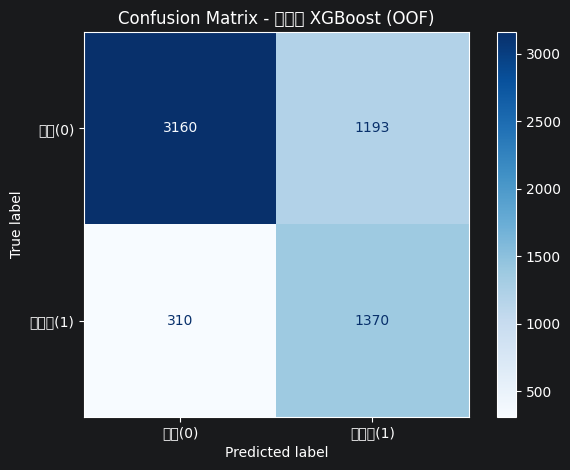

In [29]:
print(f"TN={cm[0, 0]}  FP={cm[0, 1]}")
print(f"FN={cm[1, 0]}  TP={cm[1, 1]}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["정상(0)", "고혈압(1)"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - 고혈압 XGBoost (OOF)")
plt.tight_layout()
plt.show()

## 6. ROC 커브

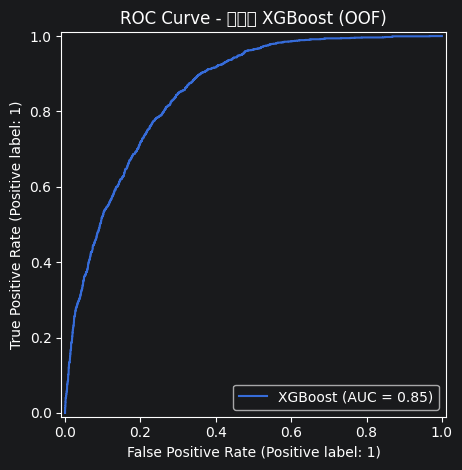

In [30]:
RocCurveDisplay.from_predictions(y, oof_proba, name="XGBoost")
plt.title("ROC Curve - 고혈압 XGBoost (OOF)")
plt.tight_layout()
plt.show()

## 7. Threshold 분석

In [31]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
threshold_results = []

print(f"{'Threshold':>10} {'Recall':>8} {'Precision':>10} {'F1':>8} {'FP':>8}")
print("-" * 48)
for t in thresholds:
    pred_t = (oof_proba >= t).astype(int)
    cm_t = confusion_matrix(y, pred_t)
    rec = recall_score(y, pred_t)
    prec = precision_score(y, pred_t)
    f1 = f1_score(y, pred_t)
    fp = cm_t[0, 1]
    threshold_results.append({"threshold": t, "recall": rec, "precision": prec, "f1": f1, "fp": fp})
    marker = "  ◀ default" if t == 0.5 else ""
    print(f"{t:>10.2f} {rec:>8.4f} {prec:>10.4f} {f1:>8.4f} {fp:>8}{marker}")

thr_df = pd.DataFrame(threshold_results)

 Threshold   Recall  Precision       F1       FP
------------------------------------------------
      0.30   0.9244     0.4623   0.6164     1806
      0.35   0.9125     0.4800   0.6291     1661
      0.40   0.8923     0.4965   0.6380     1520
      0.45   0.8571     0.5103   0.6397     1382
      0.50   0.8155     0.5345   0.6458     1193  ◀ default
      0.55   0.7714     0.5618   0.6501     1011
      0.60   0.6940     0.5859   0.6354      824


## 8. Threshold별 지표 시각화

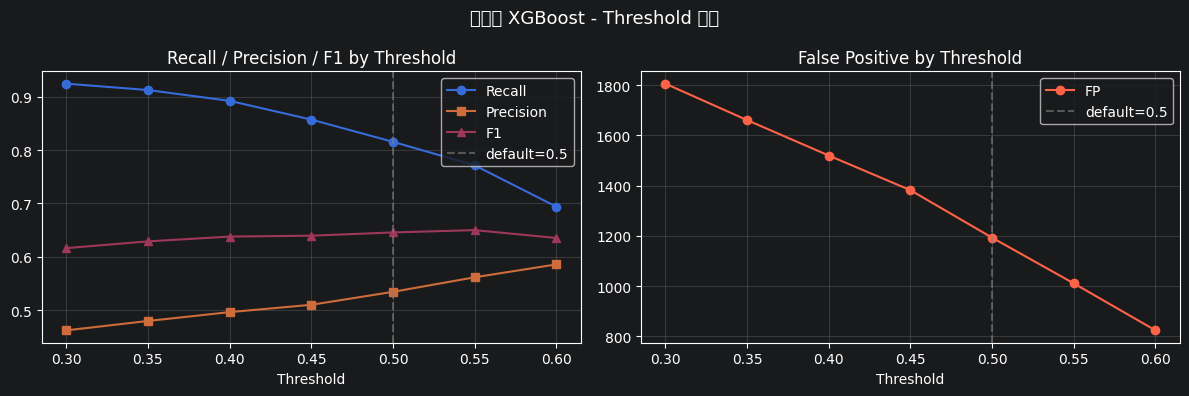

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Recall / Precision / F1
axes[0].plot(thr_df.threshold, thr_df.recall, marker="o", label="Recall")
axes[0].plot(thr_df.threshold, thr_df.precision, marker="s", label="Precision")
axes[0].plot(thr_df.threshold, thr_df.f1, marker="^", label="F1")
axes[0].axvline(0.5, color="gray", linestyle="--", alpha=0.6, label="default=0.5")
axes[0].set_xlabel("Threshold")
axes[0].set_title("Recall / Precision / F1 by Threshold")
axes[0].legend()
axes[0].grid(alpha=0.3)

# FP
axes[1].plot(thr_df.threshold, thr_df.fp, marker="o", color="tomato", label="FP")
axes[1].axvline(0.5, color="gray", linestyle="--", alpha=0.6, label="default=0.5")
axes[1].set_xlabel("Threshold")
axes[1].set_title("False Positive by Threshold")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("고혈압 XGBoost - Threshold 분석", fontsize=13)
plt.tight_layout()
plt.show()

## 9. Feature Importance Top 15 (gain, 마지막 fold)

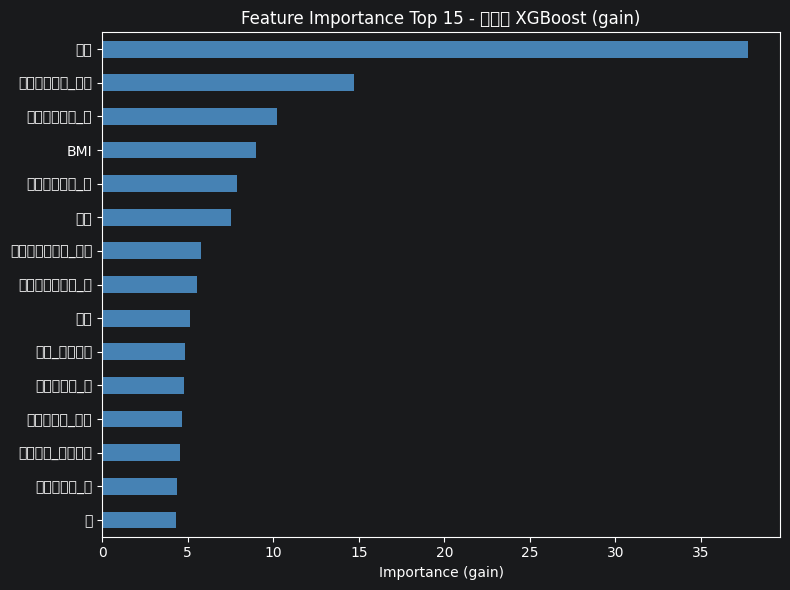

   1. 나이: 37.7
   2. 고혈압가족력_형제: 14.7
   3. 고혈압가족력_모: 10.2
   4. BMI: 9.0
   5. 고혈압가족력_부: 7.9
   6. 체중: 7.5
   7. 고지혈증가족력_형제: 5.8
   8. 고지혈증가족력_모: 5.6
   9. 성별: 5.2
  10. 직업_농림어업: 4.9
  11. 당뇨가족력_부: 4.8
  12. 당뇨가족력_형제: 4.7
  13. 과거음주_현재금주: 4.5
  14. 당뇨가족력_모: 4.4
  15. 키: 4.3


In [33]:
booster = model.get_booster()
gain = pd.Series(booster.get_score(importance_type="gain"))
gain = gain.reindex(X.columns, fill_value=0).sort_values(ascending=False)
fi_top15 = gain.head(15)

plt.figure(figsize=(8, 6))
fi_top15[::-1].plot(kind="barh", color="steelblue")
plt.title("Feature Importance Top 15 - 고혈압 XGBoost (gain)")
plt.xlabel("Importance (gain)")
plt.tight_layout()
plt.show()

for i, (feat, imp) in enumerate(fi_top15.items(), 1):
    print(f"  {i:2d}. {feat}: {imp:.1f}")

## 10. DB 로그 자동 저장

In [34]:
# ── DB 로그 자동 저장 ─────────────────────────────────────
# model_logger.py 가 같은 디렉토리에 있어야 합니다.
import sys

sys.path.insert(0, "/Users/Jiyeon/Desktop/final_project/ML")
from model_logger import ModelLogger

logger = ModelLogger("/Users/Jiyeon/Desktop/final_project/ML/model_result.db")

run_id = logger.log_run(
    disease="고혈압",
    model="XGBoost",
    stage="baseline",
    params={
        "n_estimators": 500,
        "learning_rate": 0.05,
        "max_depth": 6,
        "scale_pos_weight": round(ratio, 4),
        "eval_metric": "auc",
        "early_stopping_rounds": 50,
    },
    fold_scores=scores_df.to_dict("records"),
    oof_metrics={
        "oof_auc": oof_auc,
        "oof_f1": oof_f1,
        "oof_recall": oof_rec,
        "oof_precision": oof_prec,
        "oof_accuracy": oof_acc,
        "cm": cm.tolist(),
    },
    threshold_df=thr_df.to_dict("records"),
    feature_importance=fi_top15.to_dict(),
    note="baseline. threshold=0.5 기본값 사용.",
)

print(f"저장 완료 → run_id: {run_id}")
print()
print("[전체 실험 목록]")
print(
    logger.get_runs()[
        ["run_id", "created_at", "disease", "model", "stage", "oof_auc", "oof_recall", "oof_f1"]
    ].to_string(index=False)
)

[ModelLogger] 저장 완료 | run_id=3 | 고혈압 XGBoost (baseline)
저장 완료 → run_id: 3

[전체 실험 목록]
 run_id          created_at disease   model    stage  oof_auc  oof_recall  oof_f1
      3 2026-05-15 14:38:15     고혈압 XGBoost baseline 0.853083    0.815476 0.64577
      2 2026-05-15 14:38:00     고혈압 XGBoost baseline 0.853083    0.815476 0.64577
      1 2026-05-15 14:35:43     고혈압 XGBoost baseline 0.853083    0.815476 0.64577
